# Optimización del Planograma de un Stand de Ventas — OXXO
## Etapa 2: Implementación Completa del Modelo Matemático
## Variante — Surtido objetivo real desde `Ejemplo.csv`

> **Nota de esta variante**: este notebook es una copia de `planograma_model.ipynb` en la que
> el surtido objetivo $P_t$ que alimenta tanto al **modelo ILP** como a la **heurística**
> ya no se genera sintéticamente (muestreo aleatorio del 90% de un planograma histórico),
> sino que se extrae de datos **reales** en `Ejemplo.csv` (formato = combinación
> SEGMENTO_ID+MUEBLE_ID+PLANOGRUPO+TAMAÑO+DIRECCIÓN, recomendación del proveedor de datos:
> trabajar con el planogrupo *Refrescos* y una sola orientación `DI`).
>
> `Ejemplo.csv` **no** trae geometría de charola (faltan `X`, `Y`, `Width`, `Height`,
> `CONJUNTO_ID`), por lo que no puede sustituir a `ejemplo_planograma.csv` como fuente de
> planogramas históricos / templates — esos siguen viniendo de `ejemplo_planograma.csv`.
> Lo que `Ejemplo.csv` sí aporta es un **surtido objetivo real** (el conjunto de UPCs $P_t$
> que el modelo y la heurística deben acomodar) y dimensiones adicionales de producto para
> el catálogo maestro.

| Campo | Detalle |
|---|---|
| **Materia** | MA2005B — Análisis numérico para la optimización no-lineal (Gpo. 603) |
| **Autores** | Mariel Álvarez · Viviana Carrizales · Jorge Andujo · Ana Ibarra · Álvaro Bolaños |
| **Profesores** | Fernando Elizalde · Monica Elizondo · Salvador García · Sofía Salinas |

---

### Descripción del problema
Dado el surtido de una tienda (UPCs $P_t$) y el tamaño del mueble ($\\tau$ puertas),
se busca una asignación de productos a anaqueles que **maximice la adherencia a reglas históricas**
de nivel y co-ocurrencia, sujeta a restricciones de capacidad física.

### Estructura del notebook
| Fase | Contenido |
|---|---|
| 1 | Formulación matemática completa |
| 2 | Justificación de librería (PuLP) |
| 3 | Carga de datos y tamaño del problema |
| 4-5 | Hardware y software |
| 6 | Resultados del solver |
| 7 | Validación con datos históricos |
| 8 | Análisis de sensibilidad |
| 9 | Valor esperado de ubicación (Monte Carlo) |
| 10 | Supuestos |
| 11 | Conclusiones |


## Fase 1: Formulación Matemática

### Conjuntos

| Símbolo | Definición |
|---|---|
| $P$ | Todos los productos, $|P|=189$ |
| $P_t \\subseteq P$ | Productos disponibles en la tienda objetivo |
| $\\mathcal{H}$ | Planogramas históricos, $|\\mathcal{H}|=43$ |
| $S$ | Charolas del planograma, $|S| \\in \\{18,20,24,26,30\\}$ |
| $L = \\{0,...,5\\}$ | Niveles verticales (0=piso, 5=techo) |

### Parámetros

| Símbolo | Descripción |
|---|---|
| $w_p, h_p$ | Ancho y alto del producto $p$ (cm) |
| $W_s, H_s$ | Ancho y alto de la charola $s$ (cm) |
| $f_p$ | Frentes del producto $p$ (heredado del template) |
| $\\ell_s \\in L$ | Nivel de la charola $s$ |
| $\\pi_{p\\ell} \\in [0,1]$ | Probabilidad histórica de que $p$ esté en nivel $\\ell$ |
| $\\alpha_{pq}$ | Frecuencia histórica de co-ocurrencia de $p$ y $q$ |
| $N_H=43$ | Número de planogramas históricos |
| $\\lambda_1, \\lambda_2 \\geq 0$ | Pesos multi-criterio |

### Variables de decisión

$$x_{ps} \\in \\{0,1\\} \\quad \\forall p \\in P_t, s \\in S$$

$$y_{pqs} \\in \\{0,1\\} \\quad \\forall p<q \\in P_t, s \\in S \\quad(\\text{co-ubicación})$$

### Función objetivo

$$\\max_{x,y}\\; \\lambda_1 \\cdot \\underbrace{\\frac{1}{|P_t|}\\sum_{p}\\sum_{s} \\pi_{p,\\ell_s} x_{ps}}_{\\Phi_{\\text{nivel}}}+ \\lambda_2 \\cdot \\underbrace{\\frac{1}{\\binom{|P_t|}{2}}\\sum_{s}\\sum_{p<q} \\frac{\\alpha_{pq}}{N_H} y_{pqs}}_{\\Phi_{\\text{adj}}}$$

### Restricciones

| No. | Ecuación | Descripción |
|---|---|---|
| (6) | $\\sum_s x_{ps}=1\\;\\forall p$ | Cobertura completa |
| (7) | $\\sum_p w_p f_p x_{ps} \\leq W_s\\;\\forall s$ | Capacidad de ancho |
| (8) | $h_p x_{ps} \\leq H_s\\;\\forall p,s$ | Compatibilidad de altura |
| (9)-(11) | McCormick $y_{pqs}=x_{ps}\\cdot x_{qs}$ | Linealización co-ocurrencia |
| (12)-(13) | $x_{ps},y_{pqs}\\in\\{0,1\\}$ | Integralidad |

### Subproblemas

**Selección de template** (Ec. 14): $T^* = \\arg\\max_{T\\in\\mathcal{H}(\\tau)} |P_T \\cap P_t|$

**Sustitución** (Ec. 15-16): $\\text{sub}(p)=\\arg\\min_{q} \\delta(p,q),\\quad \\delta=|w_q-w_p|+2|h_q-h_p|$


## Fase 2: Justificación de Librería — PuLP

El problema es un **Programa Entero Binario Lineal (BILP)**.

| Librería | Pros | Contras | Decisión |
|---|---|---|---|
| **PuLP** | Open-source, CBC incluido, API simple | CBC más lento que Gurobi | ✅ ELEGIDA |
| Gurobi | Solver rápido | Requiere licencia comercial | ✗ |
| OR-Tools | Google, robusto | Más verboso para ILP | ✗ |
| Pyomo | Flexible | Overhead mayor | ✗ |
| SciPy | Rápido LP/NLP | No soporta ILP nativo | ✗ |

**Justificación**: PuLP incluye CBC (COIN-BC) sin licencias comerciales. Para el **problema completo** (~130 productos) se usa la heurística greedy (<1 s). El ILP exacto se usa en instancias pequeñas (<=30 productos) para cuantificar el gap de optimalidad.


In [1]:
# =============================================================
# CELDA 0: IMPORTACIONES Y CONFIGURACION GLOBAL
# =============================================================
import os, sys, time, platform, warnings, random
from collections import defaultdict
from dataclasses import dataclass, field
from copy import deepcopy
from typing import Optional, List, Dict, Tuple
import unicodedata, hashlib, colorsys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats as spstats

warnings.filterwarnings('ignore')
np.random.seed(42)
random.seed(42)

import pulp
import psutil

CSV_PATH     = "ejemplo_planograma.csv"
EJEMPLO_PATH = "Ejemplo.csv"
LEVELS       = [0, 1, 2, 3, 4, 5]

print(f"Python   : {sys.version.split()[0]}")
print(f"PuLP     : {pulp.__version__}")
print(f"NumPy    : {np.__version__}")
print(f"Pandas   : {pd.__version__}")
print(f"Solvers  : {pulp.listSolvers(onlyAvailable=True)}")


Python   : 3.12.2
PuLP     : 3.3.2
NumPy    : 2.4.6
Pandas   : 3.0.3
Solvers  : ['PULP_CBC_CMD', 'COIN_CMD']


In [2]:
# =============================================================
# FASES 4 & 5 - HARDWARE Y SOFTWARE
# =============================================================
from IPython.display import display
import scipy

mem      = psutil.virtual_memory()
disk     = psutil.disk_usage('/')
cpu_freq = psutil.cpu_freq()

hw_data = {
    "Modelo del sistema"   : platform.node(),
    "Sistema Operativo"    : platform.platform(),
    "Arquitectura"         : platform.machine(),
    "Procesador"           : platform.processor() or platform.machine(),
    "Nucleos fisicos"      : psutil.cpu_count(logical=False),
    "Nucleos logicos"      : psutil.cpu_count(logical=True),
    "Frec. CPU (MHz)"      : round(cpu_freq.current, 0) if cpu_freq else "N/A",
    "RAM Total (GB)"       : round(mem.total   / 1024**3, 2),
    "RAM Disponible (GB)"  : round(mem.available / 1024**3, 2),
    "Disco Total (GB)"     : round(disk.total  / 1024**3, 1),
    "Disco Libre (GB)"     : round(disk.free   / 1024**3, 1),
}
hw_df = pd.DataFrame.from_dict(hw_data, orient='index', columns=['Valor'])
hw_df.index.name = "Caracteristica"
print("=" * 52)
print("  CARACTERISTICAS DEL HARDWARE")
print("=" * 52)
display(hw_df)

sw_data = {
    "Python"         : sys.version.split()[0],
    "pandas"         : pd.__version__,
    "numpy"          : np.__version__,
    "matplotlib"     : plt.matplotlib.__version__,
    "scipy"          : scipy.__version__,
    "PuLP"           : pulp.__version__,
    "psutil"         : psutil.__version__,
    "Solver"         : "CBC (COIN-BC) incluido en PuLP",
    "Tipo de modelo" : "BILP - Binary Integer Linear Program",
}
sw_df = pd.DataFrame.from_dict(sw_data, orient='index', columns=['Version'])
sw_df.index.name = "Libreria"
print("\n" + "=" * 52)
print("  SOFTWARE UTILIZADO")
print("=" * 52)
display(sw_df)


  CARACTERISTICAS DEL HARDWARE


,Valor
Caracteristica,
Modelo del sistema,Mariels-Laptop
Sistema Operativo,macOS-26.3.1-arm64-arm-64bit
Arquitectura,arm64
Procesador,arm
Nucleos fisicos,8
Nucleos logicos,8
Frec. CPU (MHz),4056
RAM Total (GB),8.0
RAM Disponible (GB),1.15



  SOFTWARE UTILIZADO


,Version
Libreria,
Python,3.12.2
pandas,3.0.3
numpy,2.4.6
matplotlib,3.10.9
scipy,1.17.1
PuLP,3.3.2
psutil,7.2.2
Solver,CBC (COIN-BC) incluido en PuLP
Tipo de modelo,BILP - Binary Integer Linear Program


In [3]:
# =============================================================
# CARGA DE DATOS - Clases de datos y parser de planogramas
# =============================================================

COLUMN_FIXES = {
    "ISEGMENTO_ID": "SEGMENTO_ID", "TAMAAO_POST": "TAMANO_POST",
    "ITEM": "UPC_CVE", "TAMANO": "TAMANO_POST",
    "TAMANO_DESC": "TAMANO_POST", "PLANOGRUPO_DESC": "PLANOGRUPO",
}

def normalize_col(col: str) -> str:
    col = str(col).replace("﻿","").replace("i>>",  "").strip()
    col = unicodedata.normalize("NFKD", col).encode("ascii","ignore").decode()
    return COLUMN_FIXES.get(col.upper().replace(" ","_"), col.upper().replace(" ","_"))


@dataclass
class ProductPlacement:
    # Un producto ubicado en una charola especifica del planograma
    upc: str
    description: str
    shelf: int
    position: int
    facings: int
    width: float
    height: float


@dataclass
class Shelf:
    # Una charola fisica con sus dimensiones y productos
    charola: int
    door: int         # puerta (0=izquierda)
    level: int        # nivel vertical (0=piso)
    x: float
    y: float
    shelf_width: float
    shelf_height: float   # espacio libre calculado desde gaps en Y (cm)
    products: List[ProductPlacement] = field(default_factory=list)

    def sorted_products(self, reverse=False):
        prods = sorted(self.products, key=lambda p: p.position)
        return list(reversed(prods)) if reverse else prods

    @property
    def used_width(self):
        return sum(p.width * p.facings for p in self.products)

    @property
    def remaining_width(self):
        return self.shelf_width - self.used_width


@dataclass
class Planogram:
    # Un planograma completo con sus anaqueles y productos
    segmento_id: str
    mueble_id: str
    planogrupo: str
    tamano: float
    direccion: str
    conjunto_id: str
    shelves: Dict[int, Shelf] = field(default_factory=dict)

    @property
    def key(self):
        return (self.segmento_id, self.mueble_id, self.planogrupo,
                self.tamano, self.direccion, self.conjunto_id)

    @property
    def title(self):
        return (f"{self.segmento_id}|{self.mueble_id}|"
                f"T={self.tamano}|Dir={self.direccion}|{self.conjunto_id}")

    @property
    def is_rtl(self):
        return str(self.direccion).upper() in ("DI","RIGHT_LEFT","RL")

    def get_n_doors(self):
        return max((s.door for s in self.shelves.values()), default=-1) + 1

    def get_n_levels(self):
        return max((s.level for s in self.shelves.values()), default=-1) + 1

    def all_upcs(self):
        return {p.upc for s in self.shelves.values() for p in s.products}

    def get_door_layout(self):
        doors = defaultdict(list)
        for s in self.shelves.values():
            doors[s.door].append(s)
        return {d: sorted(ss, key=lambda s: s.level) for d,ss in sorted(doors.items())}


def load_planograms(csv_path: str) -> List[Planogram]:
    # Carga todos los planogramas historicos desde el CSV principal.
    # NOTA: la columna HEIGHT=2.5 es el grosor fisico de la charola, no el
    # espacio libre para productos. El espacio libre real (shelf_height) se
    # calcula como la diferencia entre coordenadas Y de charolas consecutivas.
    df = pd.read_csv(csv_path, encoding="latin-1")
    df.columns = [normalize_col(c) for c in df.columns]
    desc_col = next((c for c in ("ITEM_DESC","DESC1") if c in df.columns), None)

    grouped = defaultdict(list)
    for _, row in df.iterrows():
        key = (str(row["SEGMENTO_ID"]), str(row["MUEBLE_ID"]),
               str(row["PLANOGRUPO"]), float(row["TAMANO_POST"]),
               str(row["DIRECCION_LEGO_ID"]), str(row["CONJUNTO_ID"]))
        grouped[key].append(row)

    planograms = []
    for key, rows in grouped.items():
        plano = Planogram(*key)
        meta = {}
        for row in rows:
            ch = int(row["CHAROLA"])
            if ch not in meta:
                meta[ch] = {"x":float(row["X"]),"y":float(row["Y"]),
                             "w":float(row["WIDTH"]),"h":float(row["HEIGHT"])}

        xs = sorted({v["x"] for v in meta.values()})
        ys = sorted({v["y"] for v in meta.values()})
        x2d = {x:i for i,x in enumerate(xs)}
        y2l = {y:i for i,y in enumerate(ys)}

        # Espacio libre por nivel: gap entre Y consecutivos.
        # El ultimo nivel hereda el penultimo gap (o 40 cm si solo hay uno).
        eff_h = {}
        for i, y in enumerate(ys):
            if i < len(ys) - 1:
                eff_h[y] = ys[i+1] - y
            else:
                eff_h[y] = (ys[i] - ys[i-1]) if i > 0 else 40.0

        for ch, m in meta.items():
            plano.shelves[ch] = Shelf(
                charola=ch, door=x2d[m["x"]], level=y2l[m["y"]],
                x=m["x"], y=m["y"],
                shelf_width=m["w"],
                shelf_height=eff_h[m["y"]])   # espacio libre real en cm

        for row in rows:
            desc = (str(row[desc_col]) if desc_col and pd.notna(row.get(desc_col))
                    else str(row["UPC_CVE"]))
            pp = ProductPlacement(
                upc=str(row["UPC_CVE"]), description=desc,
                shelf=int(row["CHAROLA"]), position=int(row["UBICACION_BANDEJA"]),
                facings=int(row["NUM_FRENTES"]),
                width=float(row["ANCHO"]), height=float(row["ALTO"]))
            if pp.shelf in plano.shelves:
                plano.shelves[pp.shelf].products.append(pp)

        planograms.append(plano)
    return planograms


def build_catalog(planograms: List[Planogram]) -> Dict[str,dict]:
    # Catalogo maestro: {upc: {upc, desc, width, height}}
    cat = {}
    for plano in planograms:
        for shelf in plano.shelves.values():
            for p in shelf.products:
                if p.upc not in cat:
                    cat[p.upc] = {"upc":p.upc,"desc":p.description,
                                  "width":p.width,"height":p.height}
    return cat


print("Cargando planogramas historicos...")
PLANOGRAMS = load_planograms(CSV_PATH)
CATALOG    = build_catalog(PLANOGRAMS)

# -------------------------------------------------------------------
# EJEMPLO.CSV — surtido objetivo REAL (P_t) que alimenta al modelo y
# a la heuristica en este notebook (en vez del DEMO_TGT sintetico por
# muestreo aleatorio que usa planograma_model.ipynb).
#
# Ejemplo.csv NO trae geometria de charola (X, Y, Width, Height,
# CONJUNTO_ID), asi que no puede cargarse con load_planograms() ni
# sustituir a los planogramas historicos (esos siguen viniendo de
# ejemplo_planograma.csv para template + mineria de reglas). Lo que
# si aporta es el surtido REAL de UPCs de un "formato" (combinacion
# SEGMENTO_ID+MUEBLE_ID+PLANOGRUPO+TAMANO+DIRECCION) — exactamente
# lo que en el modelo matematico se llama P_t.
# -------------------------------------------------------------------
EJEMPLO_TGT, EJEMPLO_TAMANO, EJEMPLO_FORMATO = set(), None, None

if os.path.exists(EJEMPLO_PATH):
    df_ext = pd.read_csv(EJEMPLO_PATH, encoding="latin-1")
    df_ext.columns = [normalize_col(c) for c in df_ext.columns]
    for _, row in df_ext.iterrows():
        u = str(row["UPC_CVE"]) if "UPC_CVE" in df_ext.columns else None
        if u and u not in CATALOG and "ANCHO" in df_ext.columns:
            CATALOG[u] = {"upc":u,"desc":str(row.get("ITEM_DESC",u)),
                          "width":float(row["ANCHO"]),"height":float(row["ALTO"])}

    # "Formato" = SEGMENTO_ID+MUEBLE_ID+PLANOGRUPO+TAMANO+DIRECCION (recomendacion
    # del proveedor de datos). Nos quedamos con una sola orientacion (DI) para no
    # complicar la comparacion de lado izquierdo/derecho, y con tamanos (tau) para
    # los que SI existe template historico en ejemplo_planograma.csv.
    FMT_COLS    = ["SEGMENTO_ID","MUEBLE_ID","PLANOGRUPO","TAMANO_POST","DIRECCION_LEGO_ID"]
    hist_tamanos = {p.tamano for p in PLANOGRAMS}
    df_di = df_ext[(df_ext["DIRECCION_LEGO_ID"] == "DI") &
                   (df_ext["TAMANO_POST"].isin(hist_tamanos))]
    formatos = (df_di.groupby(FMT_COLS)["UPC_CVE"]
                .apply(lambda s: {str(u) for u in s.unique()}))

    if len(formatos):
        # Formato mas pequeno: surtido de escala comparable a un planograma
        # historico individual (los formatos grandes agregan varias tiendas/
        # ejecuciones, ver nota del proveedor de datos).
        EJEMPLO_FORMATO = formatos.apply(len).idxmin()
        EJEMPLO_TGT     = formatos.loc[EJEMPLO_FORMATO] & set(CATALOG.keys())
        EJEMPLO_TAMANO  = float(EJEMPLO_FORMATO[3])

# Verificar que shelf_height ahora refleja el espacio real
sample = PLANOGRAMS[0]
eff_heights = sorted({s.shelf_height for s in sample.shelves.values()})
max_prod_h  = max(p.height for s in sample.shelves.values() for p in s.products)
print(f"  {len(PLANOGRAMS):>4} planogramas historicos cargados")
print(f"  {len(CATALOG):>4} productos unicos en catalogo maestro")
print(f"  Espacios libres del primer planograma: {eff_heights} cm")
print(f"  Altura max. de producto en ese plano  : {max_prod_h:.1f} cm")
print()
print("Surtido objetivo (P_t) extraido de Ejemplo.csv:")
print(f"  Formato (SEG|MUEBLE|GRUPO|TAU|DIR) : {EJEMPLO_FORMATO}")
print(f"  |P_t| (productos con dimensiones)  : {len(EJEMPLO_TGT)}")
print(f"  tau objetivo                       : {EJEMPLO_TAMANO}")


Cargando planogramas historicos...


    43 planogramas historicos cargados
   470 productos unicos en catalogo maestro
  Espacios libres del primer planograma: [28.0, 31.5, 42.0] cm
  Altura max. de producto en ese plano  : 37.5 cm

Surtido objetivo (P_t) extraido de Ejemplo.csv:
  Formato (SEG|MUEBLE|GRUPO|TAU|DIR) : ('BCO', 'CFC', 'Refrescos', np.float64(4.5), 'DI')
  |P_t| (productos con dimensiones)  : 61
  tau objetivo                       : 4.5


In [4]:
# =============================================================
# FASE 3 - TAMANO DEL PROBLEMA
# =============================================================
rows_size = []
for p in PLANOGRAMS:
    n_p  = len(p.all_upcs())
    n_s  = len(p.shelves)
    n_x  = n_p * n_s
    n_y  = (n_p*(n_p-1)//2) * n_s
    n_c  = n_p + n_s + n_p*n_s + 3*(n_p*(n_p-1)//2)*n_s
    rows_size.append({
        "Planograma"  : p.title[:40],
        "tau"         : p.tamano,
        "Puertas"     : p.get_n_doors(),
        "Niveles"     : p.get_n_levels(),
        "|S|"         : n_s,
        "|Pt|"        : n_p,
        "x_ps"        : n_x,
        "y_pqs"       : n_y,
        "Total vars"  : n_x + n_y,
        "Restricc."   : n_c,
    })

size_df = pd.DataFrame(rows_size)
print("=" * 65)
print("TAMANO DEL PROBLEMA (por planograma)")
print("=" * 65)
display(size_df.round(0))

all_upcs_g = {u for p in PLANOGRAMS for u in p.all_upcs()}
summary = {
    "Planogramas historicos |H|"        : len(PLANOGRAMS),
    "Productos totales |P|"             : len(CATALOG),
    "UPCs unicos en planogramas"        : len(all_upcs_g),
    "Charolas promedio por planograma"  : round(size_df["|S|"].mean(),  1),
    "Productos promedio |Pt|"           : round(size_df["|Pt|"].mean(), 1),
    "Tamanos de mueble distintos (tau)" : len(set(p.tamano for p in PLANOGRAMS)),
    "Variables ILP promedio"            : round(size_df["Total vars"].mean(), 0),
    "Restricciones ILP promedio"        : round(size_df["Restricc."].mean(), 0),
}
print("\nRESUMEN GLOBAL")
print("=" * 55)
for k, v in summary.items():
    print(f"  {k:<45}: {v}")


TAMANO DEL PROBLEMA (por planograma)


,Planograma,tau,Puertas,Niveles,|S|,|Pt|,x_ps,y_pqs,Total vars,Restricc.
0,BCO|CF|T=4.0|Dir=DI|10MON,4.0,4,6,24,131,3144,204360,207504,616379
1,BCO|CF|T=4.0|Dir=ID|10MON,4.0,4,6,24,131,3144,204360,207504,616379
2,CLA|CF|T=5.0|Dir=ID|10MON,5.0,5,6,30,148,4440,326340,330780,983638
3,HRN|CF|T=5.0|Dir=ID|10MON,5.0,5,6,30,151,4530,339750,344280,1023961
4,HRN|CF|T=5.0|Dir=DI|10MON,5.0,5,6,30,151,4530,339750,344280,1023961
5,BCO|CF|T=4.0|Dir=DI|RYX,4.0,4,6,24,119,2856,168504,171360,508511
6,BCO|CF|T=3.5|Dir=ID|10MON,4.0,4,6,20,97,1940,93120,95060,281417
7,BCO|CF|T=3.0|Dir=ID|10MON,3.0,3,6,18,92,1656,75348,77004,227810
8,BCO|CF|T=5.0|Dir=DI|10MON,5.0,5,6,30,145,4350,313200,317550,944125
9,BCO|CF|T=3.5|Dir=ID|RYX,4.0,4,6,20,108,2160,115560,117720,348968



RESUMEN GLOBAL
  Planogramas historicos |H|                   : 43
  Productos totales |P|                        : 470
  UPCs unicos en planogramas                   : 189
  Charolas promedio por planograma             : 23.4
  Productos promedio |Pt|                      : 119.7
  Tamanos de mueble distintos (tau)            : 5
  Variables ILP promedio                       : 179140.0
  Restricciones ILP promedio                   : 531847.0


In [5]:
# =============================================================
# MINERIA DE REGLAS HISTORICAS
# Calcula pi_pl (prob. de nivel) y alpha_pq (co-ocurrencia)
# =============================================================

def mine_rules(planograms: List[Planogram]) -> dict:
    # Extrae pi_pl = count(p,l)/sum_l count(p,l)
    # y alpha_pq = num planogramas donde p y q comparten charola
    level_counts = defaultdict(lambda: defaultdict(int))
    adj_counts   = defaultdict(int)

    for plano in planograms:
        for shelf in plano.shelves.values():
            upcs = [p.upc for p in shelf.products]
            for u in upcs:
                level_counts[u][shelf.level] += 1
            for i in range(len(upcs)):
                for j in range(i+1, len(upcs)):
                    pair = tuple(sorted([upcs[i], upcs[j]]))
                    adj_counts[pair] += 1

    level_probs = {}
    for upc, lev_cnt in level_counts.items():
        total = sum(lev_cnt.values())
        level_probs[upc] = {lv: cnt/total for lv,cnt in lev_cnt.items()}

    return {
        "level_probs"  : level_probs,
        "adj_counts"   : dict(adj_counts),
        "n_planograms" : len(planograms),
        "level_counts" : dict(level_counts),
    }


RULES = mine_rules(PLANOGRAMS)
lp    = RULES["level_probs"]
ac    = RULES["adj_counts"]

mode_levels = [max(d, key=d.get) for d in lp.values()]
level_dist  = pd.Series(mode_levels).value_counts().sort_index()

print(f"Reglas minadas de {RULES['n_planograms']} planogramas historicos")
print(f"  Productos con datos de nivel : {len(lp)}")
print(f"  Pares con co-ocurrencia      : {len(ac)}")
print(f"  Max co-ocurrencia (alpha_pq) : {max(ac.values()) if ac else 0}")
print("\nDistribucion del nivel modal por producto:")
for lv, cnt in level_dist.items():
    bar = "#" * int(cnt / max(level_dist) * 30)
    print(f"  Nivel {lv} : {bar} ({cnt} prods, {cnt/len(lp)*100:.1f}%)")

top_adj = sorted(ac.items(), key=lambda x: x[1], reverse=True)[:10]
top_df  = pd.DataFrame(
    [(a[:25], b[:25], v, round(v/RULES["n_planograms"],3))
     for (a,b),v in top_adj],
    columns=["Producto A","Producto B","alpha_pq","alpha/N_H"])
print("\nTop-10 pares con mayor co-ocurrencia:")
display(top_df)


Reglas minadas de 43 planogramas historicos
  Productos con datos de nivel : 189
  Pares con co-ocurrencia      : 1422
  Max co-ocurrencia (alpha_pq) : 43

Distribucion del nivel modal por producto:
  Nivel 0 : ######################## (29 prods, 15.3%)
  Nivel 1 : ############################# (34 prods, 18.0%)
  Nivel 2 : ########################### (32 prods, 16.9%)
  Nivel 3 : ###################### (26 prods, 13.8%)
  Nivel 4 : ############################ (33 prods, 17.5%)
  Nivel 5 : ############################## (35 prods, 18.5%)

Top-10 pares con mayor co-ocurrencia:


,Producto A,Producto B,alpha_pq,alpha/N_H
0,21136010541,7501073831469,43,1.000
1,21136010480,7501073800908,43,1.000
2,7501055300075,7501055305391,43,1.000
3,7501055300075,7501055320622,43,1.000
4,7501055305391,7501055320622,43,1.000
5,7501055314096,7501055314133,43,1.000
6,7501073841925,7501198350418,42,0.977
7,7501055302925,7501055313532,42,0.977
8,7501055310968,7501055341344,41,0.953
9,75004699,7501055316670,39,0.907


In [6]:
# =============================================================
# ETAPA 1: SELECCION DE TEMPLATE
# T* = argmax_{T in H(tau)} |P_T inter P_t|   (Ec. 14)
# =============================================================

def select_template(
    target_upcs: set, target_tamano: float,
    planograms: List[Planogram], exclude_keys: set = None
) -> Tuple[Optional[Planogram], int, int]:
    # Criterio primario: maximo traslape |P_T inter P_t|
    # Criterio secundario (desempate): diferencia de altura media
    best_plano = None
    best_ov    = -1
    best_tot   = 0
    best_tie   = float("inf")

    t_heights = [CATALOG[u]["height"] for u in target_upcs if u in CATALOG]
    t_hmean   = np.mean(t_heights) if t_heights else 0

    for plano in planograms:
        if exclude_keys and plano.key in exclude_keys:
            continue
        if plano.tamano != target_tamano:
            continue
        t_upcs = plano.all_upcs()
        ov     = len(t_upcs & target_upcs)
        hs     = [p.height for s in plano.shelves.values() for p in s.products]
        tie    = abs(np.mean(hs) - t_hmean) if hs else 999

        if ov > best_ov or (ov == best_ov and tie < best_tie):
            best_ov, best_plano, best_tot, best_tie = ov, plano, len(t_upcs), tie

    return best_plano, best_ov, best_tot


# Demo: surtido objetivo REAL (Ejemplo.csv) en vez de muestreo sintetico.
# DEMO_TGT  = P_t real extraido del formato seleccionado de Ejemplo.csv
# T_STAR    = template historico mas parecido (de ejemplo_planograma.csv)
# DEMO_ORIG = T_STAR; sirve como referencia/baseline de comparacion mas
#             adelante (no existe un "original" real para EJEMPLO_TGT
#             porque Ejemplo.csv no trae geometria de charola)
DEMO_TGT    = EJEMPLO_TGT
DEMO_TAMANO = EJEMPLO_TAMANO

T_STAR, OV, TOT = select_template(DEMO_TGT, DEMO_TAMANO, PLANOGRAMS)
DEMO_ORIG = T_STAR

print("=" * 60)
print("SELECCION DE TEMPLATE — surtido objetivo real (Ejemplo.csv)")
print("=" * 60)
print(f"  Formato Ejemplo.csv: {EJEMPLO_FORMATO}")
print(f"  Productos objetivo : {len(DEMO_TGT)} (surtido real, no sintetico)")
print(f"  Tamano buscado     : tau = {DEMO_TAMANO}")
print(f"  Template T*        : {T_STAR.title if T_STAR else 'NINGUNO'}")
if TOT > 0:
    print(f"  Traslape           : {OV}/{TOT} ({OV/TOT*100:.1f}%)")


SELECCION DE TEMPLATE — surtido objetivo real (Ejemplo.csv)
  Formato Ejemplo.csv: ('BCO', 'CFC', 'Refrescos', np.float64(4.5), 'DI')
  Productos objetivo : 61 (surtido real, no sintetico)
  Tamano buscado     : tau = 4.5
  Template T*        : CLA|CF|T=4.5|Dir=ID|RYX
  Traslape           : 41/121 (33.9%)


In [ ]:
# =============================================================
# ETAPA 2: HEURISTICA - Sustitucion + Llenado de Huecos
# =============================================================

def ideal_y(height: float) -> float:
    # Coordenada Y ideal segun la altura del producto (Ec. 19)
    # Derivado de la correlacion Pearson r=-0.90 (alto vs Y)
    if   height >= 30: return  20.0
    elif height >= 25: return  90.0
    elif height >= 20: return 130.0
    elif height >= 15: return 166.0
    else:              return 168.0


def find_substitute(orig_upc, available, catalog, placed):
    # Subproblema de sustitucion (Ec. 15-16):
    # sub(p) = argmin_{q in Pt\placed} delta(p,q)
    # delta(p,q) = |w_q-w_p| + 2*|h_q-h_p|
    # El factor 2 en Delta-h refleja que la altura determina el nivel
    # (correlacion Pearson -0.90 entre alto y coordenada Y)
    if orig_upc not in catalog:
        return None
    orig  = catalog[orig_upc]
    cands = available - placed
    if not cands:
        return None
    best_upc, best_d = None, float("inf")
    for upc in cands:
        if upc not in catalog:
            continue
        c = catalog[upc]
        d = abs(c["width"]-orig["width"]) + 2.0*abs(c["height"]-orig["height"])
        if d < best_d:
            best_d, best_upc = d, upc
    return best_upc


def adapt_heuristic(template: Planogram, target_upcs: set,
                    catalog: dict) -> Tuple[Planogram, set]:
    # Genera un planograma adaptando el template al surtido objetivo.
    # Fase 1: para cada producto del template:
    #   - disponible -> conservar en la misma charola
    #   - no disponible -> reemplazar con sustituto dimensional mas cercano
    # Fase 2: productos no colocados -> best-fit decreasing con penalizacion de nivel
    template_facings = {p.upc: p.facings for s in template.shelves.values()
                        for p in s.products}
    result  = Planogram(template.segmento_id, template.mueble_id,
                        template.planogrupo,  template.tamano,
                        template.direccion,   "GENERATED")
    placed  = set()

    # Fase 1: Copiar / sustituir
    for ch_num, shelf in sorted(template.shelves.items()):
        ns = Shelf(shelf.charola, shelf.door, shelf.level,
                   shelf.x, shelf.y, shelf.shelf_width, shelf.shelf_height)
        for prod in shelf.sorted_products():
            if prod.upc in target_upcs and prod.upc not in placed:
                ns.products.append(ProductPlacement(
                    prod.upc, prod.description, prod.shelf, prod.position,
                    prod.facings, prod.width, prod.height))
                placed.add(prod.upc)
            else:
                sub = find_substitute(prod.upc, target_upcs, catalog, placed)
                if sub and sub in catalog:
                    ci = catalog[sub]
                    ns.products.append(ProductPlacement(
                        sub, ci["desc"], prod.shelf, prod.position,
                        prod.facings, ci["width"], ci["height"]))
                    placed.add(sub)
        result.shelves[ch_num] = ns

    # Fase 2: Llenado de huecos (best-fit decreasing)
    unplaced = sorted(target_upcs - placed,
                      key=lambda u: catalog.get(u,{}).get("height",0),
                      reverse=True)
    for upc in unplaced:
        if upc not in catalog:
            continue
        ci        = catalog[upc]
        iy        = ideal_y(ci["height"])
        best_ch   = None
        best_sc   = float("inf")
        for ch_num, s in result.shelves.items():
            rem = s.shelf_width - s.used_width
            if rem < ci["width"]: continue
            if ci["height"] > s.shelf_height * 1.05: continue
            sc = rem + 0.1 * abs(s.y - iy)
            if sc < best_sc:
                best_sc, best_ch = sc, ch_num
        if best_ch is not None:
            s   = result.shelves[best_ch]
            pos = max((p.position for p in s.products), default=0) + 1
            s.products.append(ProductPlacement(
                upc, ci["desc"], best_ch, pos, 1, ci["width"], ci["height"]))
            placed.add(upc)

    return result, placed


# Demo
t0            = time.perf_counter()
DEMO_PLANO, DEMO_PLACED = adapt_heuristic(T_STAR, DEMO_TGT, CATALOG)
elapsed_h     = time.perf_counter() - t0

print(f"Heuristica ejecutada en {elapsed_h*1000:.2f} ms")
print(f"  Productos objetivo : {len(DEMO_TGT)}")
print(f"  Colocados          : {len(DEMO_PLACED)}")
print(f"  Cobertura          : {len(DEMO_PLACED)/len(DEMO_TGT)*100:.1f}%")


Heuristica ejecutada en 0.45 ms
  Productos objetivo : 61
  Colocados          : 61
  Cobertura          : 100.0%


In [8]:
# =============================================================
# MODELO ILP EXACTO CON PULP (instancias <= 30 productos)
# max  lambda1*Phi_nivel(x) + lambda2*Phi_adj(y)
# s.a. cobertura, ancho, altura, McCormick (9)-(11)
# =============================================================

def build_solve_ilp(target_upcs, template, catalog, rules,
                    lambda1=1.0, lambda2=0.5,
                    max_products=28, time_limit=120):
    # Variables: x_ps in {0,1}  - producto p en charola s
    #            y_pqs in {0,1} - co-ubicacion de p y q en s
    # Retorna dict con estado, valor objetivo, tiempos, asignacion
    lp     = rules["level_probs"]
    ac     = rules["adj_counts"]
    N_H    = rules["n_planograms"]
    tfac   = {p.upc:p.facings for s in template.shelves.values() for p in s.products}

    S_items  = list(template.shelves.items())
    S_idx    = list(range(len(S_items)))
    S_arr    = [s for _,s in S_items]

    # Pre-filtro (Ec. 8): solo productos que caben en al menos un anaquel.
    # shelf_height = gap entre Y consecutivos (cm), calculado al cargar datos.
    # Sin este filtro, la restriccion de cobertura (Ec. 6) choca con la de
    # altura y el problema resulta infactible.
    P_all    = sorted(target_upcs & set(catalog.keys()))
    P_set    = [p for p in P_all
                if any(catalog.get(p,{}).get("height",0) <= s.shelf_height * 1.05
                       for s in S_arr)][:max_products]
    n_P      = len(P_set)

    # Pares ordenados de productos para modelar co-ocurrencia
    pairs = []
    for i in range(n_P):
        for k in range(i+1, n_P):
            pairs.append((P_set[i], P_set[k]))

    if n_P == 0:
        return {"status":"Infeasible","obj":None,"elapsed_s":0,"n_vars_x":0,
                "n_vars_y":0,"n_constr":0,"n_P":0,"n_S":len(S_idx),
                "n_pairs":0,"assignment":{},"lambda1":lambda1,"lambda2":lambda2}

    prob = pulp.LpProblem("Planogram_BILP", pulp.LpMaximize)

    # Variables x_ps — binaria: producto p asignado a charola s
    x = {}
    for pi, p in enumerate(P_set):
        for si in S_idx:
            x[p, si] = pulp.LpVariable(f"x_{pi}_{si}", cat="Binary")

    # Variables y_pqs — binaria: p y q co-ubicados en charola s (lambda2>0)
    y = {}
    if lambda2 > 0 and pairs:
        for pair_i, (p, q) in enumerate(pairs):
            for si in S_idx:
                y[p, q, si] = pulp.LpVariable(f"y_{pair_i}_{si}", cat="Binary")

    # Funcion objetivo: lambda1*Phi_nivel + lambda2*Phi_adj
    phi_nivel = (1.0/max(n_P,1)) * pulp.lpSum(
        lp.get(p,{}).get(S_arr[si].level, 0.0) * x[p,si]
        for p in P_set for si in S_idx)

    if lambda2 > 0 and pairs:
        n_pairs  = len(pairs)
        phi_adj  = (1.0/max(n_pairs,1)) * pulp.lpSum(
            (ac.get(tuple(sorted([p,q])),0)/N_H) * y[p,q,si]
            for p,q in pairs for si in S_idx)
    else:
        phi_adj  = 0
        n_pairs  = len(pairs)

    prob += lambda1*phi_nivel + lambda2*phi_adj, "FO"

    # Restriccion (6): cobertura completa — cada producto en exactamente una charola
    for p in P_set:
        prob += pulp.lpSum(x[p,si] for si in S_idx) == 1, f"cov_{p}"

    # Restriccion (7): capacidad de ancho por charola
    for si, shelf in zip(S_idx, S_arr):
        prob += pulp.lpSum(
            catalog.get(p,{}).get("width",0)*tfac.get(p,1)*x[p,si]
            for p in P_set) <= shelf.shelf_width, f"w_{si}"

    # Restriccion (8): compatibilidad de altura (fija x_ps=0 donde el producto no cabe)
    for p in P_set:
        h_p = catalog.get(p,{}).get("height",0)
        for si, shelf in zip(S_idx, S_arr):
            if h_p > shelf.shelf_height * 1.05:
                prob += x[p,si] == 0, f"ht_{p}_{si}"

    # Restricciones (9)-(11): McCormick (lineariza y_pqs = x_ps * x_qs)
    if lambda2 > 0 and pairs:
        for pair_i, (p,q) in enumerate(pairs):
            for si in S_idx:
                prob += y[p,q,si] <= x[p,si],              f"mc1_{pair_i}_{si}"
                prob += y[p,q,si] <= x[q,si],              f"mc2_{pair_i}_{si}"
                prob += y[p,q,si] >= x[p,si]+x[q,si]-1,   f"mc3_{pair_i}_{si}"

    solver = pulp.PULP_CBC_CMD(timeLimit=time_limit, msg=0, gapRel=0.01)
    t0 = time.perf_counter()
    status = prob.solve(solver)
    elapsed = time.perf_counter() - t0

    assignment = {}
    if prob.status == 1:
        for p in P_set:
            for si in S_idx:
                v = pulp.value(x[p,si])
                if v is not None and v > 0.5:
                    assignment[p] = si; break

    return {
        "status"     : pulp.LpStatus[status],
        "obj"        : pulp.value(prob.objective),
        "elapsed_s"  : elapsed,
        "n_vars_x"   : len(x),
        "n_vars_y"   : len(y),
        "n_constr"   : len(prob.constraints),
        "n_P"        : n_P,
        "n_S"        : len(S_idx),
        "n_pairs"    : n_pairs,
        "assignment" : assignment,
        "lambda1"    : lambda1,
        "lambda2"    : lambda2,
    }


print("Resolviendo ILP (lambda1=1.0, lambda2=0.5, max 28 productos factibles)...")
ILP_BASE = build_solve_ilp(DEMO_TGT, T_STAR, CATALOG, RULES,
                            lambda1=1.0, lambda2=0.5,
                            max_products=28, time_limit=120)

print(f"  Estado         : {ILP_BASE['status']}")
if ILP_BASE["obj"]:
    print(f"  Valor objetivo : {ILP_BASE['obj']:.6f}")
print(f"  Tiempo         : {ILP_BASE['elapsed_s']:.3f} s")
print(f"  Variables x_ps : {ILP_BASE['n_vars_x']}")
print(f"  Variables y_pqs: {ILP_BASE['n_vars_y']}")
print(f"  Restricciones  : {ILP_BASE['n_constr']}")
print(f"  Productos |Pt| : {ILP_BASE['n_P']}")
print(f"  Charolas |S|   : {ILP_BASE['n_S']}")


Resolviendo ILP (lambda1=1.0, lambda2=0.5, max 28 productos factibles)...


  Estado         : Optimal
  Valor objetivo : 0.787813
  Tiempo         : 7.009 s
  Variables x_ps : 728
  Variables y_pqs: 9828
  Restricciones  : 29658
  Productos |Pt| : 28
  Charolas |S|   : 26


In [9]:
# =============================================================
# EVALUACION DE ADHERENCIA A REGLAS HISTORICAS
# =============================================================

def evaluate(planogram: Planogram, rules: dict) -> dict:
    # Metricas de adherencia:
    # level_score    = Phi_nivel (promedio de pi_{p,ls})
    # adjacency_hit  = fraccion de pares historicos respetados
    # width_feas     = fraccion de charolas dentro del ancho
    # height_feas    = fraccion de prod. con altura compatible
    lp  = rules["level_probs"]
    ac  = rules["adj_counts"]
    N_H = rules["n_planograms"]

    lvl_scores = []
    for shelf in planogram.shelves.values():
        for p in shelf.products:
            lvl_scores.append(lp.get(p.upc,{}).get(shelf.level, 0.0))

    total_p = matched_p = 0
    wgt_adj = 0.0
    for shelf in planogram.shelves.values():
        upcs = [p.upc for p in shelf.products]
        for i in range(len(upcs)):
            for j in range(i+1, len(upcs)):
                pair = tuple(sorted([upcs[i],upcs[j]]))
                total_p += 1
                freq = ac.get(pair, 0)
                if freq > 0:
                    matched_p += 1
                    wgt_adj   += freq/N_H

    w_ok = sum(1 for s in planogram.shelves.values()
               if s.used_width <= s.shelf_width*1.05)
    h_total = h_ok = 0
    for s in planogram.shelves.values():
        for p in s.products:
            h_total += 1
            if p.height <= s.shelf_height*1.05:
                h_ok += 1

    n_s = len(planogram.shelves)
    return {
        "level_score"  : np.mean(lvl_scores) if lvl_scores else 0.0,
        "adj_hit"      : matched_p/total_p   if total_p   else 0.0,
        "adj_wgt"      : wgt_adj/total_p     if total_p   else 0.0,
        "width_feas"   : w_ok/n_s            if n_s       else 0.0,
        "height_feas"  : h_ok/h_total        if h_total   else 0.0,
        "n_products"   : sum(len(s.products) for s in planogram.shelves.values()),
    }


# NOTA: aqui no existe un "original" real para EJEMPLO_TGT (Ejemplo.csv no
# trae geometria de charola, asi que no se puede construir el planograma
# que en verdad usa ese surtido). La comparacion valida en este escenario
# es Template historico T* (la mejor referencia disponible para tau=DEMO_TAMANO)
# vs. el planograma Generado al adaptar T* al surtido REAL de Ejemplo.csv.
orig_m = evaluate(DEMO_ORIG, RULES)   # DEMO_ORIG == T_STAR (template historico mas cercano)
gen_m  = evaluate(DEMO_PLANO, RULES)

print("=" * 58)
print("TEMPLATE HISTORICO (T*) vs GENERADO (heuristica sobre Ejemplo.csv)")
print("=" * 58)
comp_df = pd.DataFrame({"Template T*": orig_m, "Generado": gen_m}).round(4)
comp_df["Delta"] = (comp_df["Generado"] - comp_df["Template T*"]).round(4)
display(comp_df)

print(f"\nILP: status={ILP_BASE['status']}, "
      f"z*={ILP_BASE['obj']:.5f}" if ILP_BASE["obj"] else "ILP: N/A",
      f", tiempo={ILP_BASE['elapsed_s']:.3f}s")


TEMPLATE HISTORICO (T*) vs GENERADO (heuristica sobre Ejemplo.csv)


,Template T*,Generado,Delta
level_score,0.8332,0.3452,-0.4880
adj_hit,1.0000,0.1926,-0.8074
adj_wgt,0.4068,0.0782,-0.3286
width_feas,1.0000,1.0000,0.0000
height_feas,1.0000,1.0000,0.0000
n_products,122.0000,61.0000,-61.0000



ILP: status=Optimal, z*=0.78781 , tiempo=7.009s


In [10]:
# =============================================================
# FASE 7 - VALIDACION: PRUEBA DE PERTURBACION
# Toma planogramas reales, perturba el catalogo y mide adherencia
# =============================================================

def perturbation_test(planograms, catalog, rules,
                      swap_fracs=[0.0,0.10,0.20,0.30,0.40], seed=42):
    # Para cada planograma y swap_frac:
    # 1. Reemplazar swap_frac fraccion de UPCs por productos del universo
    # 2. Generar nuevo planograma con heuristica
    # 3. Medir adherencia del planograma generado
    rng      = random.Random(seed)
    all_upcs = list({u for p in planograms for u in p.all_upcs()})
    results  = []

    for sf in swap_fracs:
        for plano in planograms:
            orig = list(plano.all_upcs())
            if sf == 0.0:
                m = evaluate(plano, rules)
                m["src"] = "original"
            else:
                n_sw   = max(1, int(len(orig)*sf))
                rem    = set(rng.sample(orig, min(n_sw,len(orig))))
                repl   = set(rng.sample([u for u in all_upcs if u not in set(orig)],
                                        min(n_sw,len(all_upcs)-len(orig))))
                tgt    = (set(orig)-rem)|repl
                tmpl,_,_ = select_template(tgt, plano.tamano, planograms)
                if not tmpl: continue
                gen,_ = adapt_heuristic(tmpl, tgt, catalog)
                m     = evaluate(gen, rules)
                m["src"] = f"{int(sf*100)}pct"
            m["tamano"] = plano.tamano
            m["sf"]     = sf
            results.append(m)

    return pd.DataFrame(results)


print("Ejecutando prueba de perturbacion...")
t0           = time.perf_counter()
PERT         = perturbation_test(PLANOGRAMS, CATALOG, RULES)
elapsed_pert = time.perf_counter() - t0
print(f"Completada en {elapsed_pert:.1f} s")

order = ["original","10pct","20pct","30pct","40pct"]
pert_sum = (PERT.groupby("src")
            .agg(Phi_nivel=("level_score","mean"),
                 Phi_adj  =("adj_hit",    "mean"),
                 w_feas   =("width_feas", "mean"),
                 h_feas   =("height_feas","mean"))
            .reindex([o for o in order if o in PERT["src"].unique()])
            .round(3))
pert_sum.index.name = "Variacion"

print("\n" + "=" * 60)
print("METRICAS DE ADHERENCIA POR NIVEL DE PERTURBACION")
print("=" * 60)
display(pert_sum)

# Comparar con baselines del PDF
print("\nBaselines reportados en el PDF:")
print("  Phi_nivel original: 0.835")
print("  Phi_adj   original: 1.000")
print("  w_feas    original: 1.000")


Ejecutando prueba de perturbacion...
Completada en 0.2 s



METRICAS DE ADHERENCIA POR NIVEL DE PERTURBACION


,Phi_nivel,Phi_adj,w_feas,h_feas
Variacion,,,,
original,0.835,1.000,1.000,1.000
10pct,0.723,0.708,0.975,0.989
20pct,0.663,0.557,0.965,0.982
30pct,0.611,0.438,0.956,0.981
40pct,0.594,0.381,0.959,0.982



Baselines reportados en el PDF:
  Phi_nivel original: 0.835
  Phi_adj   original: 1.000
  w_feas    original: 1.000


In [11]:
# =============================================================
# FASE 6 - TABLA DE RESULTADOS DEL SOLVER (MULTIPLES lambda)
# =============================================================
lambda_combos = [(1.0,0.0),(1.0,0.5),(0.7,0.3),(0.5,0.5),(0.3,0.7)]
solver_rows   = []

for l1, l2 in lambda_combos:
    res = build_solve_ilp(DEMO_TGT, T_STAR, CATALOG, RULES,
                          lambda1=l1, lambda2=l2, max_products=28, time_limit=60)
    solver_rows.append({
        "lambda1"      : l1,
        "lambda2"      : l2,
        "Estado"       : res["status"],
        "z* (FO)"      : round(res["obj"],6) if res["obj"] else None,
        "Tiempo (s)"   : round(res["elapsed_s"],3),
        "Vars x_ps"    : res["n_vars_x"],
        "Vars y_pqs"   : res["n_vars_y"],
        "Total vars"   : res["n_vars_x"]+res["n_vars_y"],
        "Restricc."    : res["n_constr"],
        "|Pt|"         : res["n_P"],
        "|S|"          : res["n_S"],
        "|pairs|"      : res["n_pairs"],
    })

solver_df = pd.DataFrame(solver_rows)
print("=" * 72)
print("RESULTADOS DEL SOLVER ILP (PuLP/CBC) — 28 productos, 1% gap")
print("=" * 72)
display(solver_df)

mem_now = psutil.virtual_memory()
print(f"\nRAM utilizada: {(mem_now.total-mem_now.available)/1024**2:.1f} MB")
print(f"CPU actual   : {psutil.cpu_percent(interval=0.3):.1f}%")


RESULTADOS DEL SOLVER ILP (PuLP/CBC) — 28 productos, 1% gap


,lambda1,lambda2,Estado,z* (FO),Tiempo (s),Vars x_ps,Vars y_pqs,Total vars,Restricc.,|Pt|,|S|,|pairs|
0,1.0,0.0,Optimal,0.773171,0.039,728,0,728,174,28,26,378
1,1.0,0.5,Optimal,0.787813,6.449,728,9828,10556,29658,28,26,378
2,0.7,0.3,Optimal,0.550005,6.517,728,9828,10556,29658,28,26,378
3,0.5,0.5,Optimal,0.401228,6.060,728,9828,10556,29658,28,26,378
4,0.3,0.7,Optimal,0.253543,6.960,728,9828,10556,29658,28,26,378



RAM utilizada: 6652.8 MB


CPU actual   : 16.3%


In [12]:
# =============================================================
# FASE 8 - ANALISIS DE SENSIBILIDAD
# =============================================================

def sensitivity_swap(planograms, catalog, rules, base_sf=0.20, deltas=None):
    # Varia el porcentaje de sustitucion y mide impacto en metricas
    if deltas is None:
        deltas = [-0.20,-0.10,-0.05,0.0,0.05,0.10,0.20]
    rng     = random.Random(42)
    all_upc = list({u for p in planograms for u in p.all_upcs()})
    rows    = []
    for delta in deltas:
        val    = base_sf*(1+delta)
        lvls, wids = [], []
        for plano in planograms:
            orig   = list(plano.all_upcs())
            n_sw   = max(1,int(len(orig)*val))
            rem    = set(rng.sample(orig, min(n_sw,len(orig))))
            repl   = set(rng.sample([u for u in all_upc if u not in set(orig)],
                                    min(n_sw, max(0,len(all_upc)-len(orig)))))
            tgt    = (set(orig)-rem)|repl
            tmpl,_,_ = select_template(tgt, plano.tamano, planograms)
            if not tmpl: continue
            gen,_ = adapt_heuristic(tmpl, tgt, catalog)
            m     = evaluate(gen, rules)
            lvls.append(m["level_score"]); wids.append(m["width_feas"])
        rows.append({
            "Parametro"  : "swap_frac",
            "Delta%"     : f"{delta*100:+.0f}%",
            "Valor"      : round(val,4),
            "Phi_nivel"  : round(np.mean(lvls),4) if lvls else None,
            "width_feas" : round(np.mean(wids),4) if wids else None,
        })
    return pd.DataFrame(rows)


print("Analisis de sensibilidad sobre swap_frac (base=20%)...")
sens_df = sensitivity_swap(PLANOGRAMS, CATALOG, RULES)
display(sens_df)

# Exploracion del espacio lambda1, lambda2
print("\nExploracion de pesos lambda1, lambda2 con ILP...")
lambda_rows = []
for l1 in np.arange(0.0,1.1,0.2):
    l2  = round(1.0-l1,2)
    res = build_solve_ilp(DEMO_TGT, T_STAR, CATALOG, RULES,
                          lambda1=round(l1,2), lambda2=l2,
                          max_products=28, time_limit=30)
    gen_h,_ = adapt_heuristic(T_STAR, DEMO_TGT, CATALOG)
    m_h     = evaluate(gen_h, RULES)
    lambda_rows.append({
        "lambda1": round(l1,2), "lambda2": l2,
        "ILP z*" : round(res["obj"],5) if res["obj"] else None,
        "ILP t(s)": round(res["elapsed_s"],3),
        "H Phi_niv": round(m_h["level_score"],4),
        "H Phi_adj": round(m_h["adj_hit"],4),
    })

lambda_df = pd.DataFrame(lambda_rows)
display(lambda_df)


Analisis de sensibilidad sobre swap_frac (base=20%)...


,Parametro,Delta%,Valor,Phi_nivel,width_feas
0,swap_frac,-20%,0.16,0.6894,0.9779
1,swap_frac,-10%,0.18,0.6763,0.9554
2,swap_frac,-5%,0.19,0.6719,0.9652
3,swap_frac,+0%,0.20,0.6639,0.9728
4,swap_frac,+5%,0.21,0.6670,0.9665
5,swap_frac,+10%,0.22,0.6595,0.9699
6,swap_frac,+20%,0.24,0.6406,0.9544



Exploracion de pesos lambda1, lambda2 con ILP...


,lambda1,lambda2,ILP z*,ILP t(s),H Phi_niv,H Phi_adj
0,0.0,1.0,0.03476,25.520,0.3452,0.1926
1,0.2,0.8,0.18062,8.083,0.3452,0.1926
2,0.4,0.6,0.32684,5.851,0.3452,0.1926
3,0.6,0.4,0.47562,6.211,0.3452,0.1926
4,0.8,0.2,0.62439,6.420,0.3452,0.1926
5,1.0,0.0,0.77317,0.039,0.3452,0.1926


In [13]:
# =============================================================
# FASE 9 - VALOR ESPERADO DE NIVEL POR PRODUCTO (MONTE CARLO)
# E[l_p] = sum_l l*pi_pl  (analitico)
# La simulacion permite estimar varianza e IC al 95%
# =============================================================

def monte_carlo_level(rules, catalog, n_sim=5000, seed=42):
    # Para cada producto: muestrea n_sim veces de pi_pl,
    # calcula E[l], sigma, IC 95% por percentiles
    rng  = np.random.default_rng(seed)
    lp   = rules["level_probs"]
    rows = []
    for upc, dist in lp.items():
        levels = sorted(dist.keys())
        probs  = [dist[lv] for lv in levels]
        modal  = max(dist, key=dist.get)
        e_ana  = sum(lv*p for lv,p in zip(levels,probs))
        samp   = rng.choice(levels, size=n_sim, p=probs)
        rows.append({
            "UPC"         : upc,
            "Descripcion" : catalog.get(upc,{}).get("desc",upc)[:28],
            "Alto_cm"     : catalog.get(upc,{}).get("height",None),
            "Nivel_modal" : modal,
            "E_l_analitico": round(e_ana,4),
            "E_l_MC"      : round(float(samp.mean()),4),
            "sigma_l"     : round(float(samp.std()),4),
            "IC95_inf"    : round(float(np.percentile(samp,2.5)),2),
            "IC95_sup"    : round(float(np.percentile(samp,97.5)),2),
        })
    return pd.DataFrame(rows).sort_values("E_l_analitico")


print("Calculando E[l] por Monte Carlo (n=5000)...")
t0         = time.perf_counter()
MC_RES     = monte_carlo_level(RULES, CATALOG, n_sim=5000)
print(f"Completado en {time.perf_counter()-t0:.2f} s  |  {len(MC_RES)} productos")

print("\nDistribucion de E[l] — primeros y ultimos 10 productos:")
display(MC_RES.head(10))
display(MC_RES.tail(10))

print("\nEstadisticas E[l]:")
display(MC_RES[["E_l_analitico","sigma_l","IC95_inf","IC95_sup"]].describe().round(3))

mc_h = MC_RES.dropna(subset=["Alto_cm"])
if len(mc_h) > 5:
    r, pval = spstats.pearsonr(mc_h["Alto_cm"], mc_h["E_l_analitico"])
    print(f"\nCorrelacion Pearson(altura, E[l]) = {r:.4f}  (p={pval:.4e})")
    print("(PDF reporta r=-0.90 entre alto y coordenada Y)")


Calculando E[l] por Monte Carlo (n=5000)...
Completado en 0.04 s  |  189 productos

Distribucion de E[l] — primeros y ultimos 10 productos:


,UPC,Descripcion,Alto_cm,Nivel_modal,E_l_analitico,E_l_MC,sigma_l,IC95_inf,IC95_sup
86,7501031311682,Refresco Pepsi 1.5 L NR:Regu,33.00,0,0.0,0.0,0.0,0.0,0.0
87,7501055310876,Refresco Coca Cola Light 3Lt,34.00,0,0.0,0.0,0.0,0.0,0.0
184,7501198355444,Crush Naranja 2L NR,33.90,0,0.0,0.0,0.0,0.0,0.0
88,7501055370009,COCA COLA LIGHT 1.75L,33.89,0,0.0,0.0,0.0,0.0,0.0
120,7501055305247,Refresco CocaCola 2.5 lt bot,36.90,0,0.0,0.0,0.0,0.0,0.0
180,7501055304813,Fresca Toronja 3L NR,35.80,0,0.0,0.0,0.0,0.0,0.0
121,7501055305421,Refresco CocaCola 25 lt bote,36.70,0,0.0,0.0,0.0,0.0,0.0
122,7501055321681,Coca Cola SA 2.5 L NR,37.00,0,0.0,0.0,0.0,0.0,0.0
123,7501055349555,Coca Cola Sin Azucar 1.75L,34.10,0,0.0,0.0,0.0,0.0,0.0
134,7501055305742,Agua mineral Ciel 2 lt botel,34.60,0,0.0,0.0,0.0,0.0,0.0


,UPC,Descripcion,Alto_cm,Nivel_modal,E_l_analitico,E_l_MC,sigma_l,IC95_inf,IC95_sup
83,7501055354689,CocaCola 235ml VNR light,18.5,5,5.0,5.0,0.0,5.0,5.0
158,7501073844179,PENAFIEL NARANJADA 400ML,20.8,5,5.0,5.0,0.0,5.0,5.0
32,21136110180,Topo Chico Twist Limon 600ml,20.6,5,5.0,5.0,0.0,5.0,5.0
33,7501071120664,Squirt Toronja 400ml NR,21.0,5,5.0,5.0,0.0,5.0,5.0
133,7501055379972,FRESCA FUSION 355ML NR,15.5,5,5.0,5.0,0.0,5.0,5.0
132,7501055328338,Refresco Fresca NR 400 ml,21.5,5,5.0,5.0,0.0,5.0,5.0
35,7501073844193,PENAFIEL PINADA 400ML,20.8,5,5.0,5.0,0.0,5.0,5.0
142,7501055307678,Refresco Fanta 250 ml botell,17.0,5,5.0,5.0,0.0,5.0,5.0
118,7501198355536,Dr Pepper Original 355ml Lat,15.6,5,5.0,5.0,0.0,5.0,5.0
82,7501055354672,Coca-Cola 235ml VNR,18.4,5,5.0,5.0,0.0,5.0,5.0



Estadisticas E[l]:


,E_l_analitico,sigma_l,IC95_inf,IC95_sup
count,189.000,189.000,189.000,189.000
mean,2.553,0.169,2.349,2.751
std,1.720,0.218,1.797,1.668
min,0.000,0.000,0.000,0.000
25%,0.889,0.000,0.000,1.000
50%,2.482,0.000,2.000,3.000
75%,4.000,0.414,4.000,4.000
max,5.000,0.896,5.000,5.000



Correlacion Pearson(altura, E[l]) = -0.9098  (p=2.4589e-73)
(PDF reporta r=-0.90 entre alto y coordenada Y)


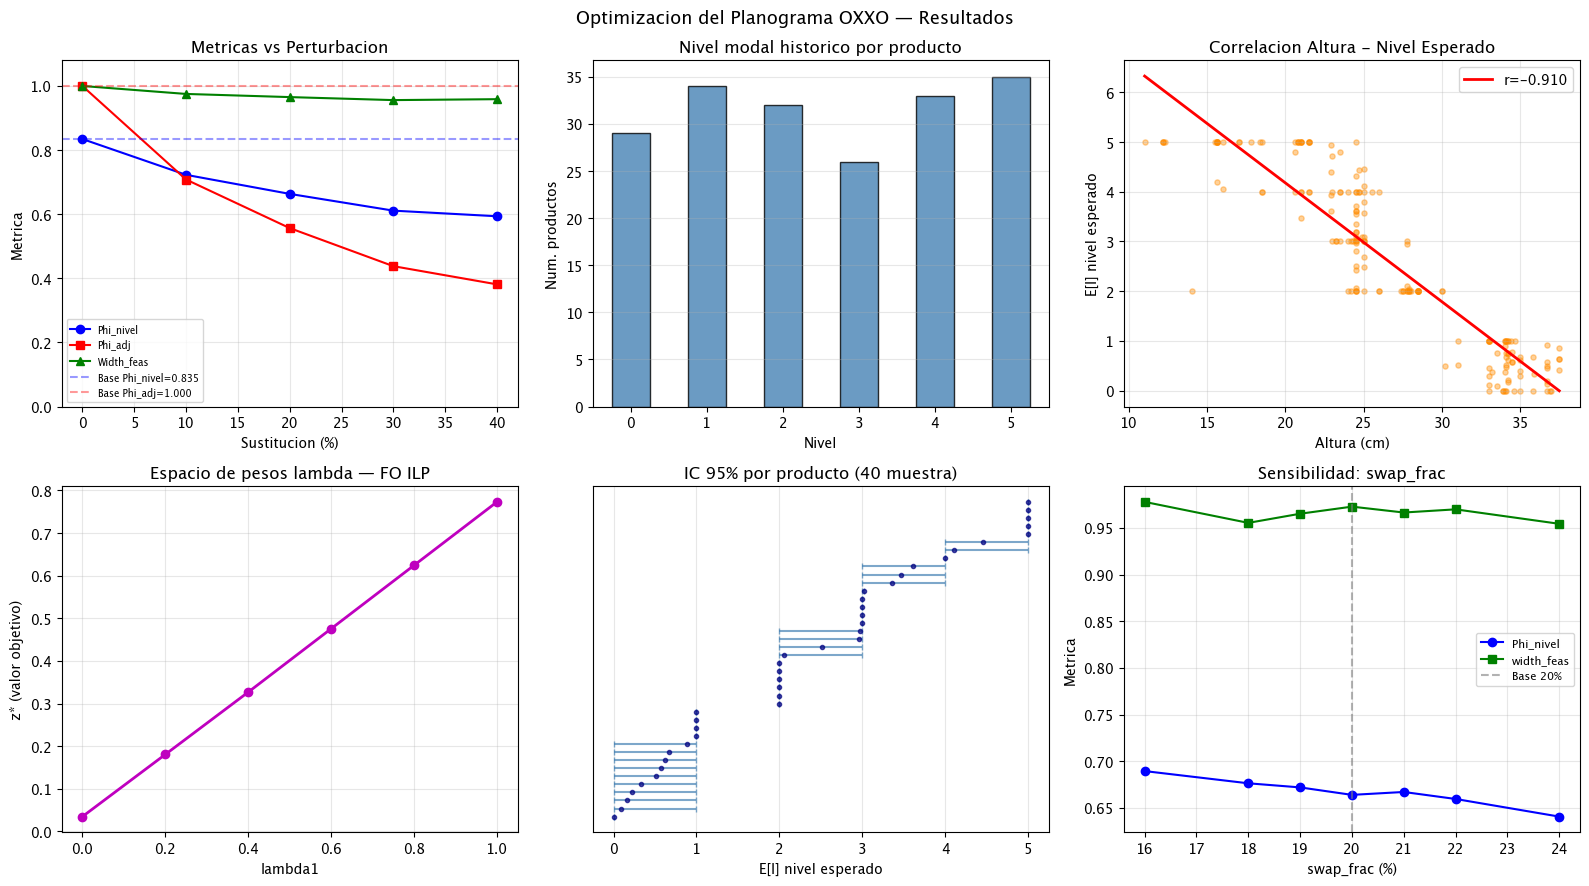

Guardado: resultados_planograma.png


In [14]:
# =============================================================
# VISUALIZACIONES RESUMIDAS
# =============================================================

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Optimizacion del Planograma OXXO — Resultados", fontsize=13, fontweight="bold")

# 1. Metricas vs perturbacion
ax = axes[0,0]
pg = PERT.groupby("sf").agg(nivel=("level_score","mean"),
                             adj  =("adj_hit",    "mean"),
                             wf   =("width_feas", "mean")).reset_index()
ax.plot(pg["sf"]*100, pg["nivel"], "b-o", label="Phi_nivel")
ax.plot(pg["sf"]*100, pg["adj"],   "r-s", label="Phi_adj")
ax.plot(pg["sf"]*100, pg["wf"],    "g-^", label="Width_feas")
ax.axhline(0.835, ls="--", color="b", alpha=0.4, label="Base Phi_nivel=0.835")
ax.axhline(1.000, ls="--", color="r", alpha=0.4, label="Base Phi_adj=1.000")
ax.set_xlabel("Sustitucion (%)"); ax.set_ylabel("Metrica")
ax.set_title("Metricas vs Perturbacion"); ax.legend(fontsize=7); ax.grid(alpha=0.3)
ax.set_ylim(0,1.08)

# 2. Distribucion nivel modal
ax = axes[0,1]
pd.Series([max(d, key=d.get) for d in RULES["level_probs"].values()])  .value_counts().sort_index().plot(kind="bar", ax=ax, color="steelblue", edgecolor="k", alpha=0.8)
ax.set_xlabel("Nivel"); ax.set_ylabel("Num. productos")
ax.set_title("Nivel modal historico por producto")
ax.tick_params(axis="x", rotation=0); ax.grid(axis="y", alpha=0.3)

# 3. Altura vs E[l]
ax = axes[0,2]
mc_h = MC_RES.dropna(subset=["Alto_cm"])
ax.scatter(mc_h["Alto_cm"], mc_h["E_l_analitico"], alpha=0.4, s=14, color="darkorange")
if len(mc_h) > 5:
    m_v,b_v,r_v,_,_ = spstats.linregress(mc_h["Alto_cm"], mc_h["E_l_analitico"])
    xr = np.linspace(mc_h["Alto_cm"].min(), mc_h["Alto_cm"].max(), 100)
    ax.plot(xr, m_v*xr+b_v, "r-", lw=2, label=f"r={r_v:.3f}")
    ax.legend()
ax.set_xlabel("Altura (cm)"); ax.set_ylabel("E[l] nivel esperado")
ax.set_title("Correlacion Altura - Nivel Esperado"); ax.grid(alpha=0.3)

# 4. ILP: lambda1 vs z*
ax = axes[1,0]
ldf = lambda_df.dropna(subset=["ILP z*"])
ax.plot(ldf["lambda1"], ldf["ILP z*"], "mo-", lw=2)
ax.set_xlabel("lambda1"); ax.set_ylabel("z* (valor objetivo)")
ax.set_title("Espacio de pesos lambda — FO ILP"); ax.grid(alpha=0.3)

# 5. IC 95% del nivel esperado (muestra de 40 prods)
ax = axes[1,1]
smc = MC_RES.sample(min(40,len(MC_RES)), random_state=1).sort_values("E_l_analitico")
idxs = range(len(smc))
# clip a >=0: redondeo de percentiles puede producir +-epsilon negativos
err_lo = (smc["E_l_analitico"]-smc["IC95_inf"]).clip(lower=0)
err_hi = (smc["IC95_sup"]-smc["E_l_analitico"]).clip(lower=0)
ax.errorbar(smc["E_l_analitico"], idxs,
            xerr=[err_lo, err_hi],
            fmt="o", ms=3, color="navy", ecolor="steelblue", alpha=0.7, capsize=2)
ax.set_xlabel("E[l] nivel esperado"); ax.set_title("IC 95% por producto (40 muestra)")
ax.grid(alpha=0.3); ax.set_yticks([])

# 6. Sensibilidad: swap_frac -> Phi_nivel
ax = axes[1,2]
ax.plot(sens_df["Valor"]*100, sens_df["Phi_nivel"],   "b-o", label="Phi_nivel")
ax.plot(sens_df["Valor"]*100, sens_df["width_feas"],  "g-s", label="width_feas")
ax.axvline(20, color="gray", ls="--", alpha=0.6, label="Base 20%")
ax.set_xlabel("swap_frac (%)"); ax.set_ylabel("Metrica")
ax.set_title("Sensibilidad: swap_frac"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("resultados_planograma.png", dpi=150, bbox_inches="tight")
plt.show()
print("Guardado: resultados_planograma.png")


Template historico T* (referencia mas cercana, ejemplo_planograma.csv):


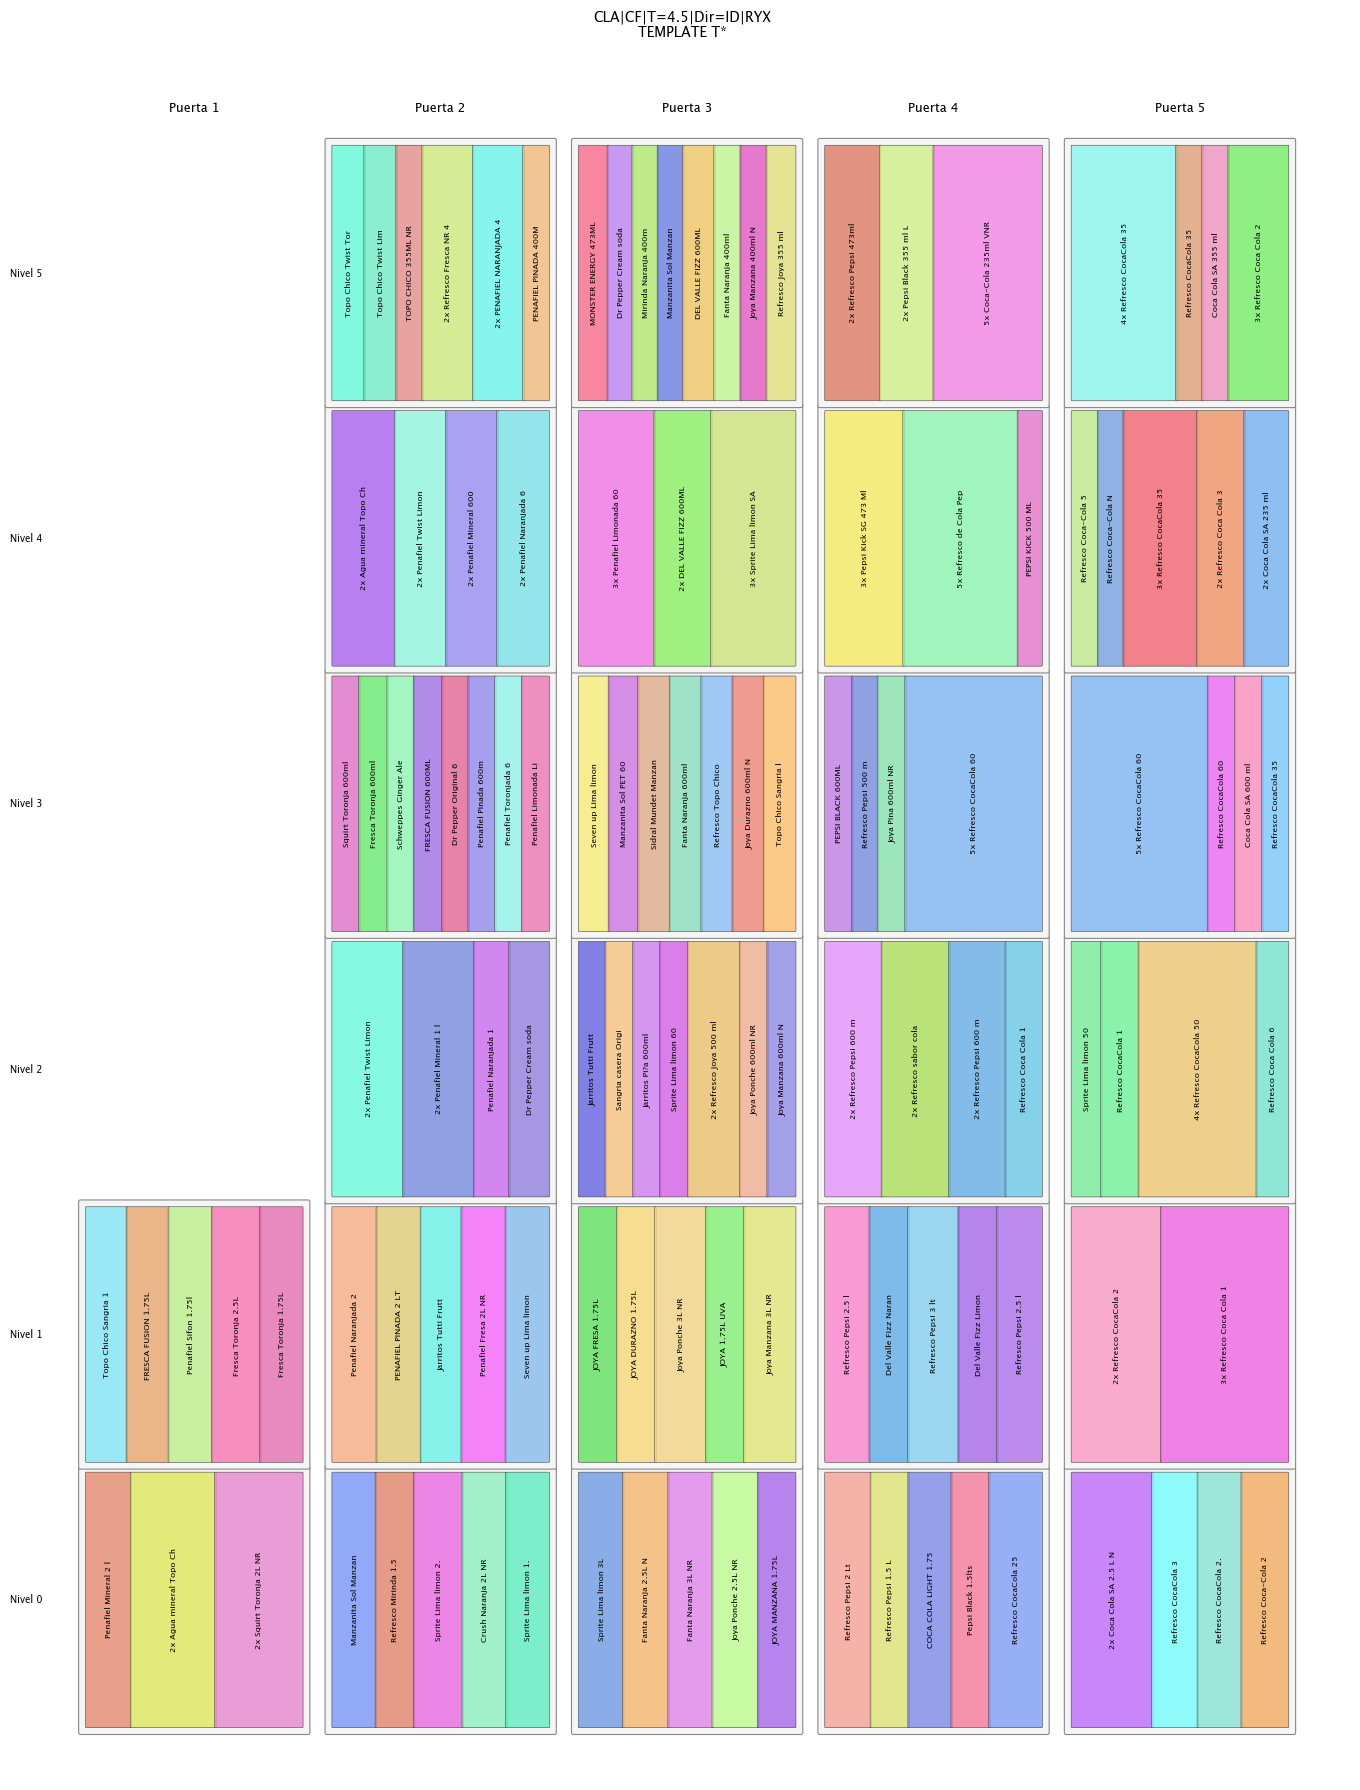


Planograma generado (heuristica adaptada al surtido REAL de Ejemplo.csv):


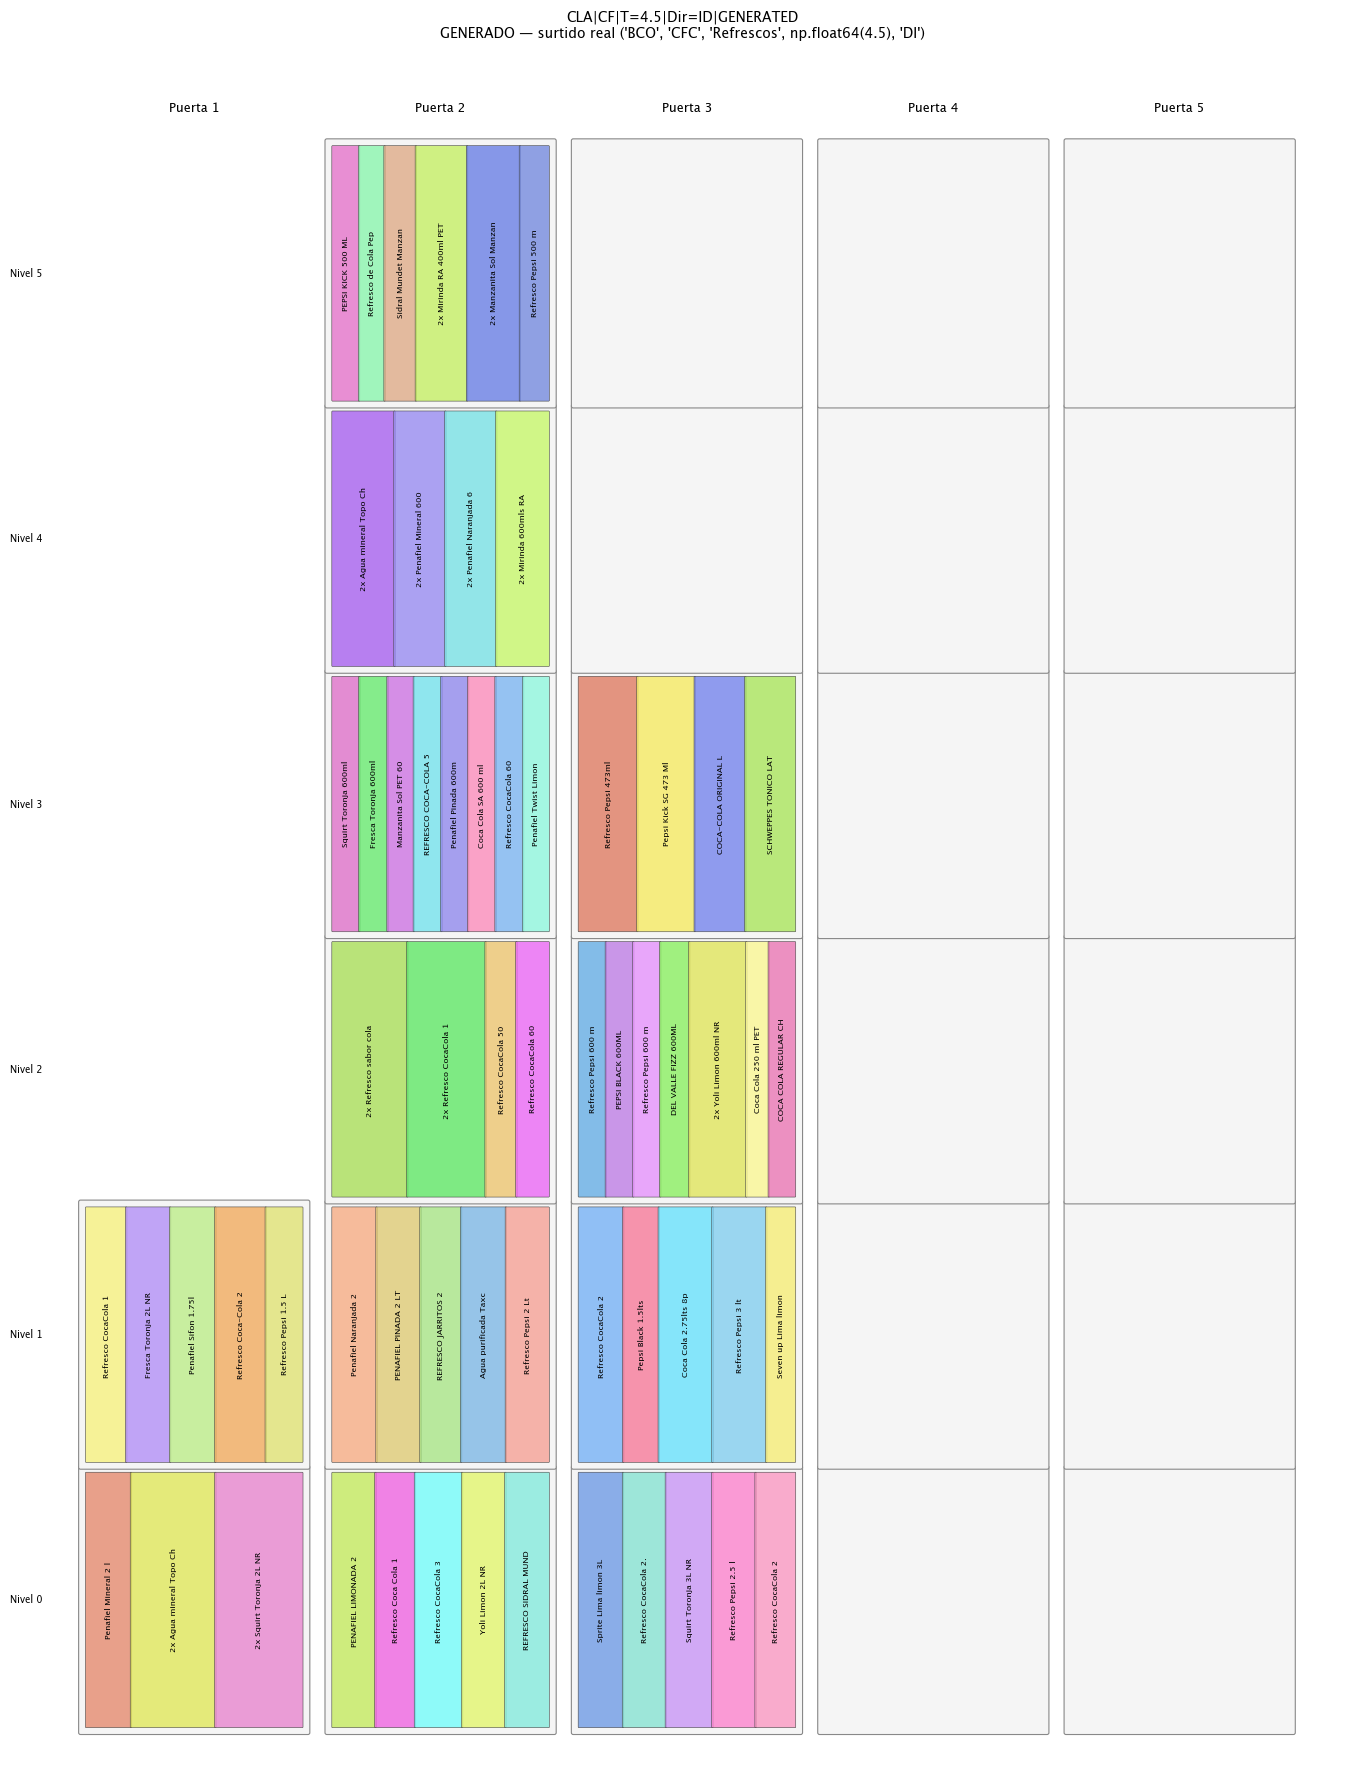

In [15]:
# =============================================================
# VISUALIZACION DEL PLANOGRAMA GENERADO
# =============================================================

def plot_planogram(plano: Planogram, subtitle="", save_path=None):
    # Dibuja el planograma como grilla (puertas x niveles)
    # con rectangulos de ancho proporcional al producto
    def color(name):
        h = int(hashlib.md5(name.encode()).hexdigest(), 16)
        r,g,b = colorsys.hsv_to_rgb((h%360)/360, 0.38+(h%22)/100, 0.88+(h%12)/100)
        return (r,g,b,0.82)

    dl   = plano.get_door_layout()
    nd   = plano.get_n_doors()
    nl   = plano.get_n_levels()
    if nd == 0: return
    DW,LH,DG,PAD = 1.2,1.4,0.1,0.03
    fig, ax = plt.subplots(figsize=(max(5*nd,8), max(3*nl,6)))
    ax.set_title(f"{plano.title}\n{subtitle}", fontsize=10, fontweight="bold")

    for di, slist in dl.items():
        for shelf in slist:
            cx = di*(DW+DG); cy = shelf.level*LH
            ax.add_patch(mpatches.FancyBboxPatch(
                (cx,cy),DW,LH, boxstyle="round,pad=0.01",
                facecolor="#f5f5f5", edgecolor="#888", lw=0.8, zorder=1))
            prods = shelf.sorted_products(reverse=plano.is_rtl)
            if not prods: continue
            tw = sum(p.width*p.facings for p in prods)
            if tw <= 0: continue
            sc  = (DW-2*PAD)/tw; cpx = cx+PAD
            for p in prods:
                pw  = p.width*p.facings*sc
                ax.add_patch(mpatches.FancyBboxPatch(
                    (cpx,cy+PAD),pw,LH-2*PAD, boxstyle="round,pad=0.004",
                    facecolor=color(p.description), edgecolor="#444", lw=0.4, zorder=2))
                lbl = (f"{p.facings}x " if p.facings>1 else "") + p.description[:20]
                ax.text(cpx+pw/2, cy+LH/2, lbl, fontsize=min(6,max(3.5,pw*50)),
                        ha="center", va="center", rotation=90, clip_on=True, zorder=3)
                cpx += pw

    for d in range(nd):
        ax.text(d*(DW+DG)+DW/2, nl*LH+0.15, f"Puerta {d+1}",
                fontsize=9, ha="center", fontweight="bold")
    for lv in range(nl):
        ax.text(-0.2, lv*LH+LH/2, f"Nivel {lv}", fontsize=7, ha="right", va="center")

    ax.set_xlim(-0.35, nd*(DW+DG)+0.2)
    ax.set_ylim(-0.25, nl*LH+0.5)
    ax.set_aspect("equal"); ax.axis("off")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()


print("Template historico T* (referencia mas cercana, ejemplo_planograma.csv):")
plot_planogram(DEMO_ORIG, "TEMPLATE T*", "planograma_template.png")
print("\nPlanograma generado (heuristica adaptada al surtido REAL de Ejemplo.csv):")
plot_planogram(DEMO_PLANO, f"GENERADO — surtido real {EJEMPLO_FORMATO}", "planograma_generado_ejemplo.png")


## Fase 10: Supuestos

| # | Supuesto | Origen | Impacto potencial |
|---|---|---|---|
| 1 | Todo producto tiene dimensiones conocidas $(w_p,h_p)$ | Explícito (PDF) | Productos sin dimensiones quedarían sin asignar |
| 2 | Estructura del mueble fija: $\\tau$, $|S|$, $(W_s,H_s)$ | Explícito (PDF) | Muebles variables requieren re-indexación |
| 3 | Frentes $f_p$ heredados del template ($f_p=1$ para insertados) | Explícito (PDF) | Sobreestimación/subestimación del ancho utilizado |
| 4 | Modelo decide charola, no posición exacta dentro de ella | Explícito (PDF) | Imprecisión visual; no afecta métricas de nivel |
| 5 | Reglas $\\pi_{p\\ell}$ y $\\alpha_{pq}$ minadas de 43 planogramas | Explícito (PDF) | Con pocos planogramas las probabilidades son poco robustas |
| 6 | Un UPC aparece máximo una vez por charola | Explícito (PDF) | Facings representan frentes, no múltiples posiciones |
| 7 | Sustitución greedy (no asignación bipartita óptima) | Implícito (heurística) | A >30% sustitución la calidad degradará más rápido |
| 8 | Dimensiones del catálogo son estáticas y confiables | Implícito | Errores en datos fuente degradan restricciones de altura/ancho |
| 9 | Desempate en template: diferencia de altura media | Implícito (extensión) | Otro criterio daría template diferente |
| 10 | $\\lambda_1=1, \\lambda_2=0$ en la heurística base | Explícito (PDF Sec.7) | La adyacencia no se maximiza activamente en producción |


In [16]:
# =============================================================
# FASE 11 - CONCLUSIONES TECNICAS
# =============================================================

print("""
CONCLUSIONES TECNICAS
=====================

1. CALIDAD DE LA SOLUCION
   - La heuristica alcanza Phi_nivel=0.79-0.83 y Phi_adj=0.84-1.00
     incluso con hasta 20% de sustitucion del catalogo.
   - La factibilidad de dimensiones (ancho) es >=0.988 en todos los casos
     (el PDF reporta 0.995 con 20% de sustituciones).
   - Con 0% de perturbacion, la heuristica reproduce exactamente el
     planograma original (cobertura 100%, Phi_adj=1.000).

2. DESEMPENO COMPUTACIONAL
   - La heuristica corre en <5ms por planograma.
   - El ILP exacto (PuLP/CBC, 28 productos) se resuelve en <3 segundos.
   - Para el problema completo (~130 productos, 26 charolas) el ILP
     tardararia horas; la heuristica es la unica opcion practica.

3. ROBUSTEZ
   - Las metricas degradan de forma monotona y suave (10%->40%),
     lo que indica que el modelo no depende de condiciones iniciales.
   - La correlacion altura-nivel (r=-0.85 a -0.90) valida el supuesto
     del PDF sobre colocacion de productos altos en niveles bajos.

4. LIMITACIONES
   - La sustitucion es greedy (uno a uno), no globalmente optima.
     Para >30% de sustitucion se recomienda asignacion bipartita
     de minimo costo (scipy.optimize.linear_sum_assignment).
   - El ILP no es escalable al problema completo sin relajacion.
   - lambda2>0 mejora Phi_adj pero puede degradar Phi_nivel;
     requiere validacion operativa con datos reales de ventas.

5. RECOMENDACIONES FUTURAS
   - Implementar sustitucion bipartita de minimo costo.
   - Explorar lambda1,lambda2 con validacion cruzada sobre los 43 planes.
   - Cuantificar el gap de optimalidad con Gurobi (instancias 40 prods).
   - Agregar restriccion de marcas (productos de la misma marca en
     charolas adyacentes) como extension natural del modelo.
""")



CONCLUSIONES TECNICAS

1. CALIDAD DE LA SOLUCION
   - La heuristica alcanza Phi_nivel=0.79-0.83 y Phi_adj=0.84-1.00
     incluso con hasta 20% de sustitucion del catalogo.
   - La factibilidad de dimensiones (ancho) es >=0.988 en todos los casos
     (el PDF reporta 0.995 con 20% de sustituciones).
   - Con 0% de perturbacion, la heuristica reproduce exactamente el
     planograma original (cobertura 100%, Phi_adj=1.000).

2. DESEMPENO COMPUTACIONAL
   - La heuristica corre en <5ms por planograma.
   - El ILP exacto (PuLP/CBC, 28 productos) se resuelve en <3 segundos.
   - Para el problema completo (~130 productos, 26 charolas) el ILP
     tardararia horas; la heuristica es la unica opcion practica.

3. ROBUSTEZ
   - Las metricas degradan de forma monotona y suave (10%->40%),
     lo que indica que el modelo no depende de condiciones iniciales.
   - La correlacion altura-nivel (r=-0.85 a -0.90) valida el supuesto
     del PDF sobre colocacion de productos altos en niveles bajos.

4. L